# PERFORMING ANN , CLASSIFICATION 
## WORKFLOW

```text
Load Dataset
      ↓
Drop Unnecessary Columns
      ↓
Label Encoding
      ↓
Train-Test Split
      ↓
StandardScaler
      ↓
Build ANN (Input → Hidden → Output)
      ↓
Compile Model
      ↓
Train Model
      ↓
Evaluate Accuracy
      ↓
Predictions
      ↓
Confusion Matrix & Classification Report
      ↓
Accuracy and Loss Graphs
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("breast.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

In [4]:
le = LabelEncoder()

df["diagnosis"] = le.fit_transform(df["diagnosis"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/500
12/12 [==============================] - 0s 7ms/step - loss: 0.0321 - accuracy: 0.9918 - val_loss: 0.0882 - val_accuracy: 0.9451
Epoch 2/500
12/12 [==============================] - 0s 5ms/step - loss: 0.0314 - accuracy: 0.9918 - val_loss: 0.0883 - val_accuracy: 0.9560
Epoch 3/500
12/12 [==============================] - 0s 4ms/step - loss: 0.0306 - accuracy: 0.9918 - val_loss: 0.0883 - val_accuracy: 0.9560
Epoch 4/500
12/12 [==============================] - 0s 5ms/step - loss: 0.0300 - accuracy: 0.9918 - val_loss: 0.0870 - val_accuracy: 0.9560
Epoch 5/500
12/12 [==============================] - 0s 4ms/step - loss: 0.0293 - accuracy: 0.9918 - val_loss: 0.0876 - val_accuracy: 0.9560
Epoch 6/500
12/12 [==============================] - 0s 5ms/step - loss: 0.0287 - accuracy: 0.9918 - val_loss: 0.0892 - val_accuracy: 0.9560
Epoch 7/500
12/12 [==============================] - 0s 4ms/step - loss: 0.0278 - accuracy: 0.9918 - val_loss: 0.0897 - val_accuracy: 0.9560
Epoch 8/500
1

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

4/4 [==============================] - 0s 2ms/step - loss: 0.2329 - accuracy: 0.9737
Test Accuracy: 0.9736841917037964


In [13]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print(y_pred[:10])

4/4 [==============================] - 0s 2ms/step
[[0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]]


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[71  0]
 [ 3 40]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



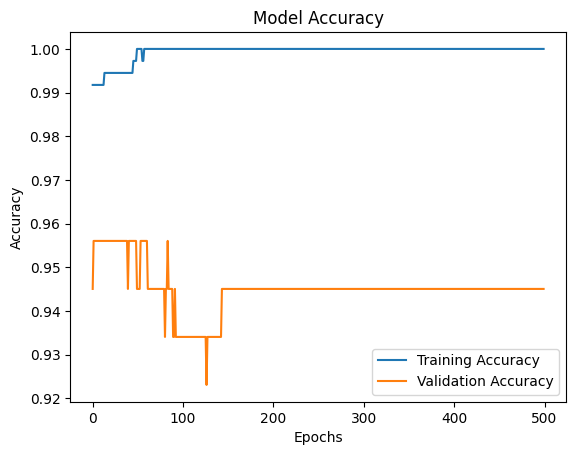

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()